# Introduction to Data Science 2026

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [24]:
import pandas as pd
df = pd.read_csv('data.csv')

print(df.head())
print(df.shape)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [25]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
df = df.drop(columns=cols_to_drop)

print(df.head(5))
print(df.shape)

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S
(891, 9)


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [26]:
df['Deck'] = df['Cabin'].str[0]

df.drop(columns=['Cabin'], inplace=True)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [27]:
print(df['Sex'].unique())
print(df['Embarked'].unique())
print(df['Deck'].unique())

['male' 'female']
['S' 'C' 'Q' nan]
[nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


In [28]:
import numpy as np
cat_col = ['Sex', 'Embarked', 'Deck']
for col in cat_col:
    df[col] = df[col].astype('category').cat.codes.replace(-1, np.nan)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,0,3,1,22.0,1,0,7.2500,2.0,NaN
1,1,1,0,38.0,1,0,71.2833,0.0,2.0
2,1,3,0,26.0,0,0,7.9250,2.0,NaN
3,1,1,0,35.0,1,0,53.1000,2.0,2.0
4,0,3,1,35.0,0,0,8.0500,2.0,NaN


5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [29]:
print(df.isnull().sum())
continuous_cols = ['Age', 'Fare']
for col in continuous_cols:
    df[col] = df[col].fillna(df[col].mean())
categorical_cols = ['Sex', 'Embarked', 'Deck']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())
df.head()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Deck        687
dtype: int64
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Deck        0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,0,3,1,22.0,1,0,7.2500,2.0,2.0
1,1,1,0,38.0,1,0,71.2833,0.0,2.0
2,1,3,0,26.0,0,0,7.9250,2.0,2.0
3,1,1,0,35.0,1,0,53.1000,2.0,2.0
4,0,3,1,35.0,0,0,8.0500,2.0,2.0


6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [6]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [30]:
df.to_csv("preprocessed_data.csv", index=False)
df.to_json("preprocessed_data.json", orient="records", indent=4)
with open("preprocessed_data.json", "r") as f:
    print(f.read()[:400])

[
    {
        "Survived":0,
        "Pclass":3,
        "Sex":1,
        "Age":22.0,
        "SibSp":1,
        "Parch":0,
        "Fare":7.25,
        "Embarked":2.0,
        "Deck":2.0
    },
    {
        "Survived":1,
        "Pclass":1,
        "Sex":0,
        "Age":38.0,
        "SibSp":1,
        "Parch":0,
        "Fare":71.2833,
        "Embarked":0.0,
        "Deck":2.0
    },
    {
 


Study the records and try to see if there is any evident pattern in terms of chances of survival.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [32]:
cat = ['Pclass', 'Sex', 'Embarked', 'Deck']
num= ['Age', 'SibSp', 'Parch', 'Fare']

for col in cat:
    print(f"Mode of {col}:", df[col].mode()[0])

for col in num:
    print(f"Median of {col}:", df[col].median())

Mode of Pclass: 3
Mode of Sex: 1
Mode of Embarked: 2.0
Mode of Deck: 2.0
Median of Age: 29.69911764705882
Median of SibSp: 0.0
Median of Parch: 0.0
Median of Fare: 14.4542


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [40]:
survivors = df[df['Survived'] == 1]
print((df[df['Survived'] == 1]))
non_survivors = df[df['Survived'] == 0]
print((df[df['Survived'] == 0]))


     Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Deck
1           1       1    0  38.0      1      0  71.2833       0.0   2.0
2           1       3    0  26.0      0      0   7.9250       2.0   2.0
3           1       1    0  35.0      1      0  53.1000       2.0   2.0
8           1       3    0  27.0      0      2  11.1333       2.0   2.0
9           1       2    0  14.0      1      0  30.0708       0.0   2.0
..        ...     ...  ...   ...    ...    ...      ...       ...   ...
875         1       3    0  15.0      0      0   7.2250       0.0   2.0
879         1       1    0  56.0      0      1  83.1583       0.0   2.0
880         1       2    0  25.0      0      1  26.0000       2.0   2.0
887         1       1    0  19.0      0      0  30.0000       2.0   1.0
889         1       1    1  26.0      0      0  30.0000       0.0   2.0

[342 rows x 9 columns]
     Survived  Pclass  Sex        Age  SibSp  Parch     Fare  Embarked  Deck
0           0       3    1  22.0000

In [41]:
average_survivor = {}
average_non_survivor = {}

for col in cat:
    average_survivor[col] = survivors[col].mode()[0]
    average_non_survivor[col] = non_survivors[col].mode()[0]

for col in num:
    average_survivor[col] = survivors[col].median()
    average_non_survivor[col] = non_survivors[col].median()

profile_df = pd.DataFrame({
    'Average Survivor': pd.Series(average_survivor),
    'Average Non-Survivor': pd.Series(average_non_survivor)
})

profile_df

,Average Survivor,Average Non-Survivor
Pclass,1.000000,3.000000
Sex,0.000000,1.000000
Embarked,2.000000,2.000000
Deck,2.000000,2.000000
Age,29.699118,29.699118
SibSp,0.000000,0.000000
Parch,0.000000,0.000000
Fare,26.000000,10.500000


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

In [ ]:
%pip install matplotlib

Matplotlib is building the font cache; this may take a moment.


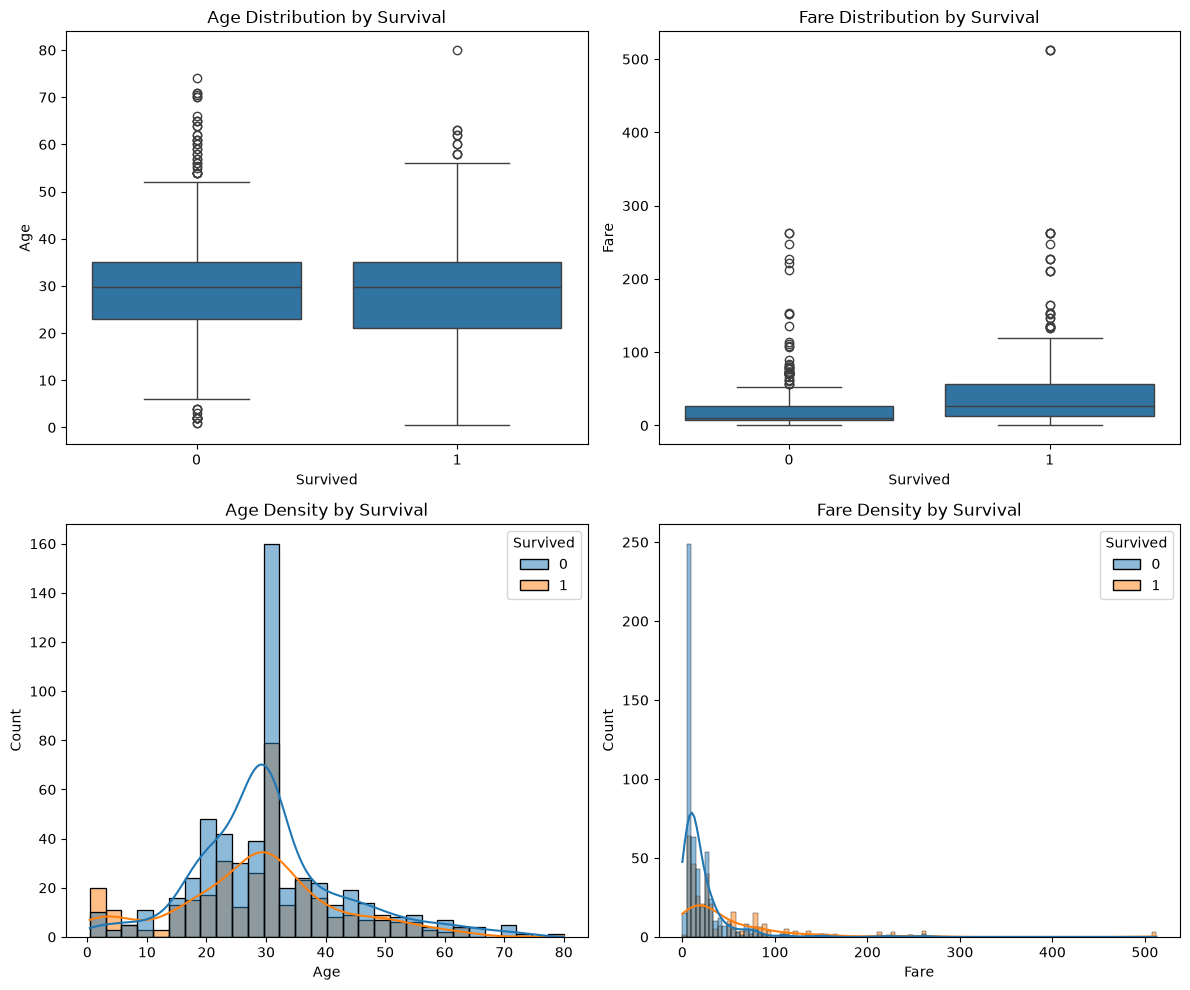

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Survival')
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[0, 1])
axes[0, 1].set_title('Fare Distribution by Survival')
sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Density by Survival')
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Fare Density by Survival')
plt.tight_layout()
plt.show()


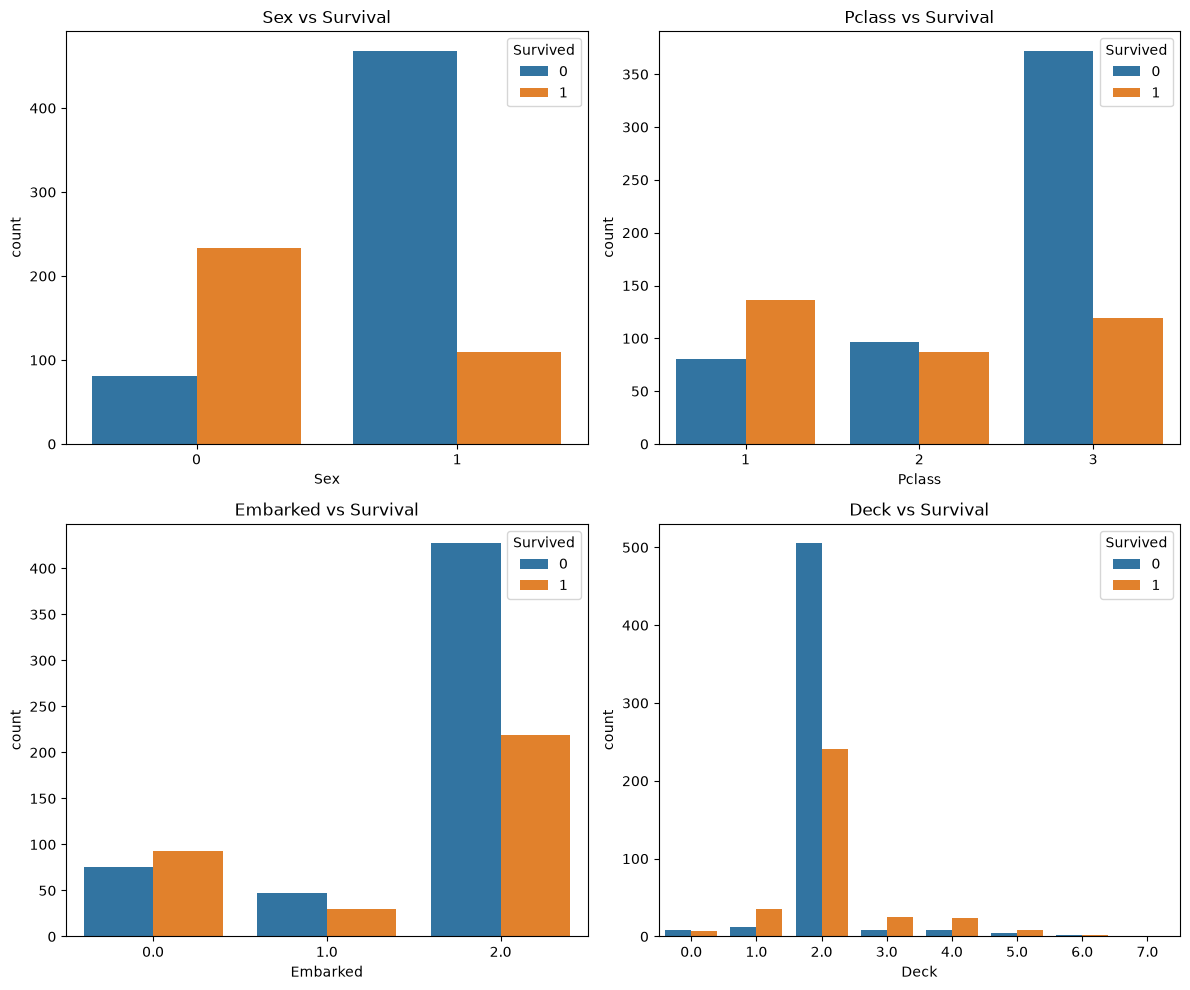

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Sex vs Survival')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Pclass vs Survival')

sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Embarked vs Survival')

sns.countplot(data=df, x='Deck', hue='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Deck vs Survival')

plt.tight_layout()
plt.show()

In [ ]:
# Passengers Matching the Average Survivor
survivor_prototype = profile_df['Average Survivor']

survivors_matching_own = df[
    (df['Survived'] == 1) &
    (df['Sex'] == survivor_prototype['Sex']) &
    (df['Pclass'] == survivor_prototype['Pclass']) &
    (abs(df['Age'] - survivor_prototype['Age']) <= 5)
]

survivors_matching_own.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
31,1,1,0,29.699118,1,0,146.5208,0.0,1.0
166,1,1,0,29.699118,0,1,55.0000,2.0,4.0
215,1,1,0,31.000000,1,0,113.2750,0.0,3.0
218,1,1,0,32.000000,0,0,76.2917,0.0,3.0
256,1,1,0,29.699118,0,0,79.2000,0.0,2.0


In [49]:
# Passengers Matching the Average Non Survivor
survivor_prototype = profile_df['Average Non-Survivor']

nonsurvivors_matching_own = df[
    (df['Survived'] == 0) &
    (df['Sex'] == survivor_prototype['Sex']) &
    (df['Pclass'] == survivor_prototype['Pclass']) &
    (abs(df['Age'] - survivor_prototype['Age']) <= 5)
]

nonsurvivors_matching_own.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
5,0,3,1,29.699118,0,0,8.4583,1.0,2.0
26,0,3,1,29.699118,0,0,7.2250,0.0,2.0
29,0,3,1,29.699118,0,0,7.8958,2.0,2.0
42,0,3,1,29.699118,0,0,7.8958,0.0,2.0
45,0,3,1,29.699118,0,0,8.0500,2.0,2.0


In [ ]:
#Non-Survivors Matching the Average Survivor Profile
non_survivors_matching_survivor_profile = df[
    (df['Survived'] == 0) &
    (df['Sex'] == survivor_prototype['Sex']) &
    (df['Pclass'] == survivor_prototype['Pclass']) &
    (abs(df['Age'] - survivor_prototype['Age']) <= 5)
]

non_survivors_matching_survivor_profile.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
498,0,1,0,25.0,1,2,151.55,2.0,2.0


In [50]:
#Survivors Matching the Average Non-Survivor Profile
non_survivor_prototype = profile_df['Average Non-Survivor']

survivors_matching_non_survivor_profile = df[
    (df['Survived'] == 1) &
    (df['Sex'] == non_survivor_prototype['Sex']) &
    (df['Pclass'] == non_survivor_prototype['Pclass']) &
    (abs(df['Age'] - non_survivor_prototype['Age']) <= 5)
]

survivors_matching_non_survivor_profile.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
36,1,3,1,29.699118,0,0,7.2292,0.0,2.0
65,1,3,1,29.699118,1,1,15.2458,0.0,2.0
74,1,3,1,32.000000,0,0,56.4958,2.0,2.0
81,1,3,1,29.000000,0,0,9.5000,2.0,2.0
107,1,3,1,29.699118,0,0,7.7750,2.0,2.0


4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

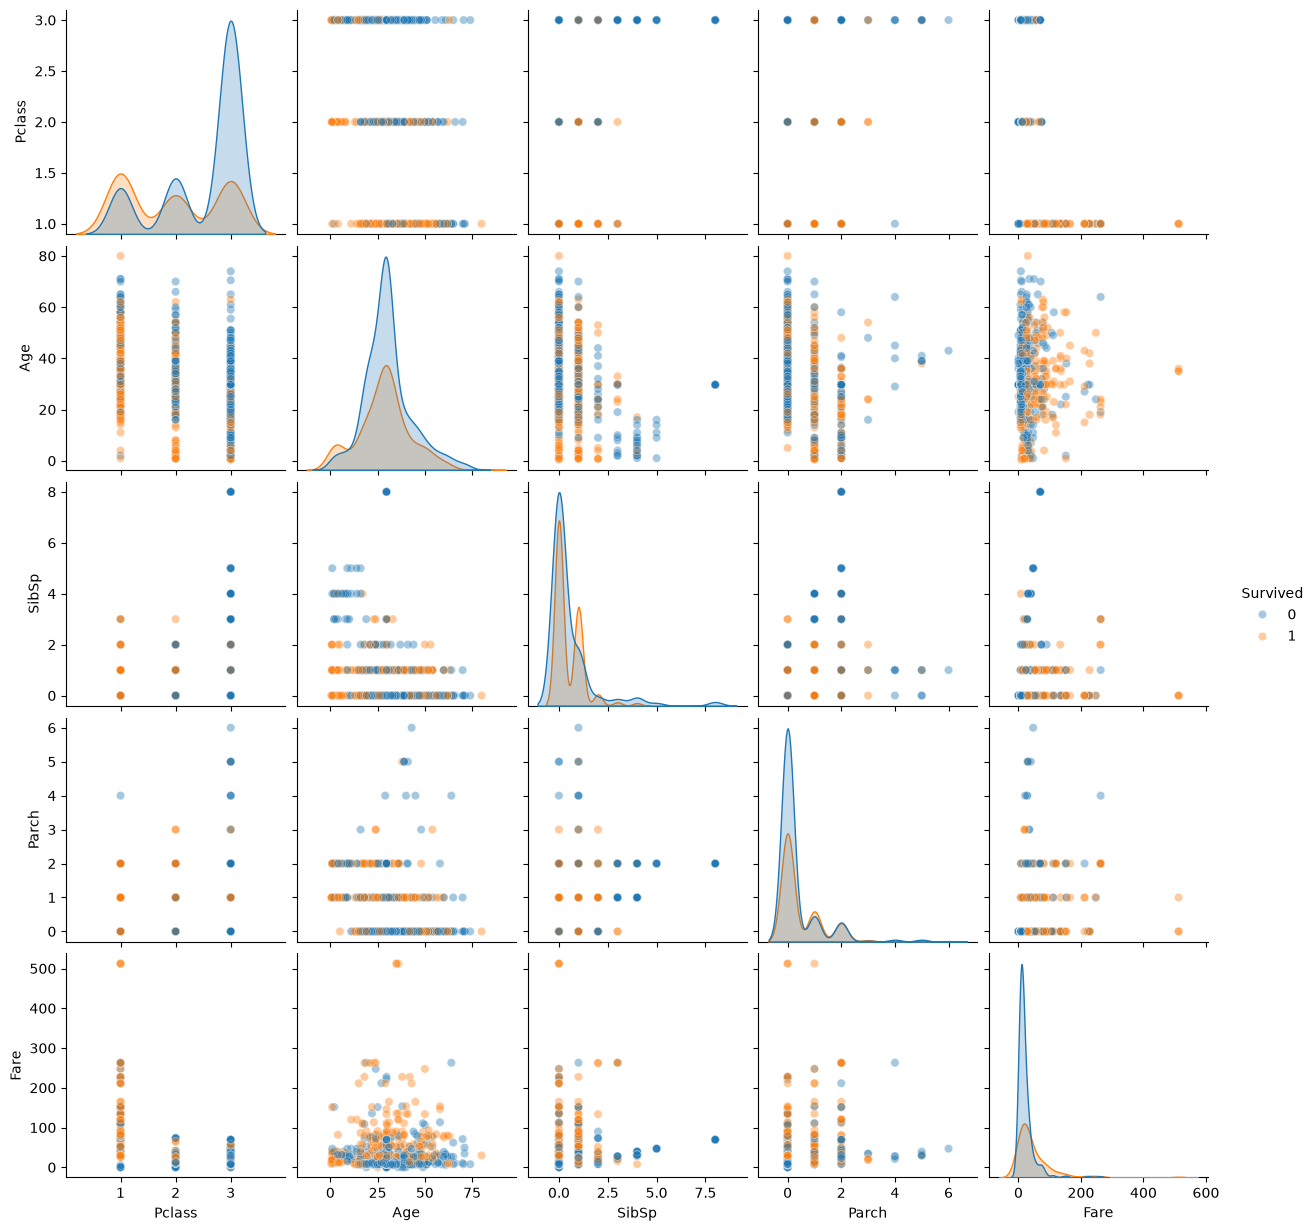

In [52]:
sns.pairplot(
    data=df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']],
    hue='Survived',
    palette='tab10',
    plot_kws={'alpha': 0.4}
)
plt.show()

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

About 687 of values were missing in the Cabin Column, if we had removed all of it instead of imputing, it might've created a bias in the dataset and trends and patterns would've been way less accurate and difficult to spot.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [53]:
from collections import Counter
import re
with open('/Users/nivedharengaraj/Downloads/coursework/DS/pos.txt', 'r', encoding='utf-8') as f:
    pos_text = f.read()
with open('/Users/nivedharengaraj/Downloads/coursework/DS/neg.txt', 'r', encoding='utf-8') as f:
    neg_text = f.read()

In [54]:
pos_words = re.findall(r'\b\w+\b', pos_text.lower())
neg_words = re.findall(r'\b\w+\b', neg_text.lower())
pos_counts = Counter(pos_words)
neg_counts = Counter(neg_words)
print("Top 10 Most Common in POSITIVE:")
for word, count in pos_counts.most_common(10):
    print(f"{word}: {count}")
print("\nTop 10 Most Common in NEGATIVE:")
for word, count in neg_counts.most_common(10):
    print(f"{word}: {count}")

Top 10 Most Common in POSITIVE:
great: 435907
work: 427780
use: 345234
good: 291448
fit: 273505
instal: 229408
product: 210085
look: 181401
just: 180420
like: 175725

Top 10 Most Common in NEGATIVE:
work: 39998
use: 37244
fit: 31294
product: 24394
just: 23581
light: 22907
like: 20685
time: 19665
look: 18824
instal: 18709


2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([pos_text, neg_text])

print("TF-IDF Matrix shape (2 x m):", tfidf_matrix.shape)
print("Number of unique words (m):", len(vectorizer.get_feature_names_out()))

TF-IDF Matrix shape (2 x m): (2, 235325)
Number of unique words (m): 235325


3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [56]:
feature_names = np.array(vectorizer.get_feature_names_out())

pos_scores = tfidf_matrix[0].toarray().flatten()
neg_scores = tfidf_matrix[1].toarray().flatten()

top_n = 10

top_pos_indices = pos_scores.argsort()[::-1][:top_n]
top_neg_indices = neg_scores.argsort()[::-1][:top_n]

top_pos_df = pd.DataFrame({
    'Positive Word': feature_names[top_pos_indices],
    'TF-IDF': pos_scores[top_pos_indices]
})

top_neg_df = pd.DataFrame({
    'Negative Word': feature_names[top_neg_indices],
    'TF-IDF': neg_scores[top_neg_indices]
})

print("--- Top 10 Positive Words ---")
print(top_pos_df)

print("\n--- Top 10 Negative Words ---")
print(top_neg_df)


--- Top 10 Positive Words ---
  Positive Word    TF-IDF
0         great  0.366787
1          work  0.359948
2           use  0.290491
3          good  0.245234
4           fit  0.230136
5        instal  0.193032
6       product  0.176773
7          look  0.152637
8          just  0.151811
9          like  0.147861

--- Top 10 Negative Words ---
  Negative Word    TF-IDF
0          work  0.301801
1           use  0.281021
2           fit  0.236126
3       product  0.184062
4          just  0.177928
5         light  0.172842
6          like  0.156076
7          time  0.148380
8          look  0.142034
9        instal  0.141167


In [ ]:
#The top 10 TF-IDF words are identical in both identity and ranking to the most common words from Task 1.
#Did TF-IDF work as expected? No. 
# Because we treated the entire dataset as only two massive documents, every frequent word appears in both documents, giving them all the exact same IDF score of $1.0$. 
# Consequently, the IDF component failed to penalize shared words, and TF-IDF simply reproduced raw term frequencies.

4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

/var/folders/kx/qxglm7wd5zb28wv7z9lncnhc0000gn/T/ipykernel_51448/1900089536.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/kx/qxglm7wd5zb28wv7z9lncnhc0000gn/T/ipykernel_51448/1900089536.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


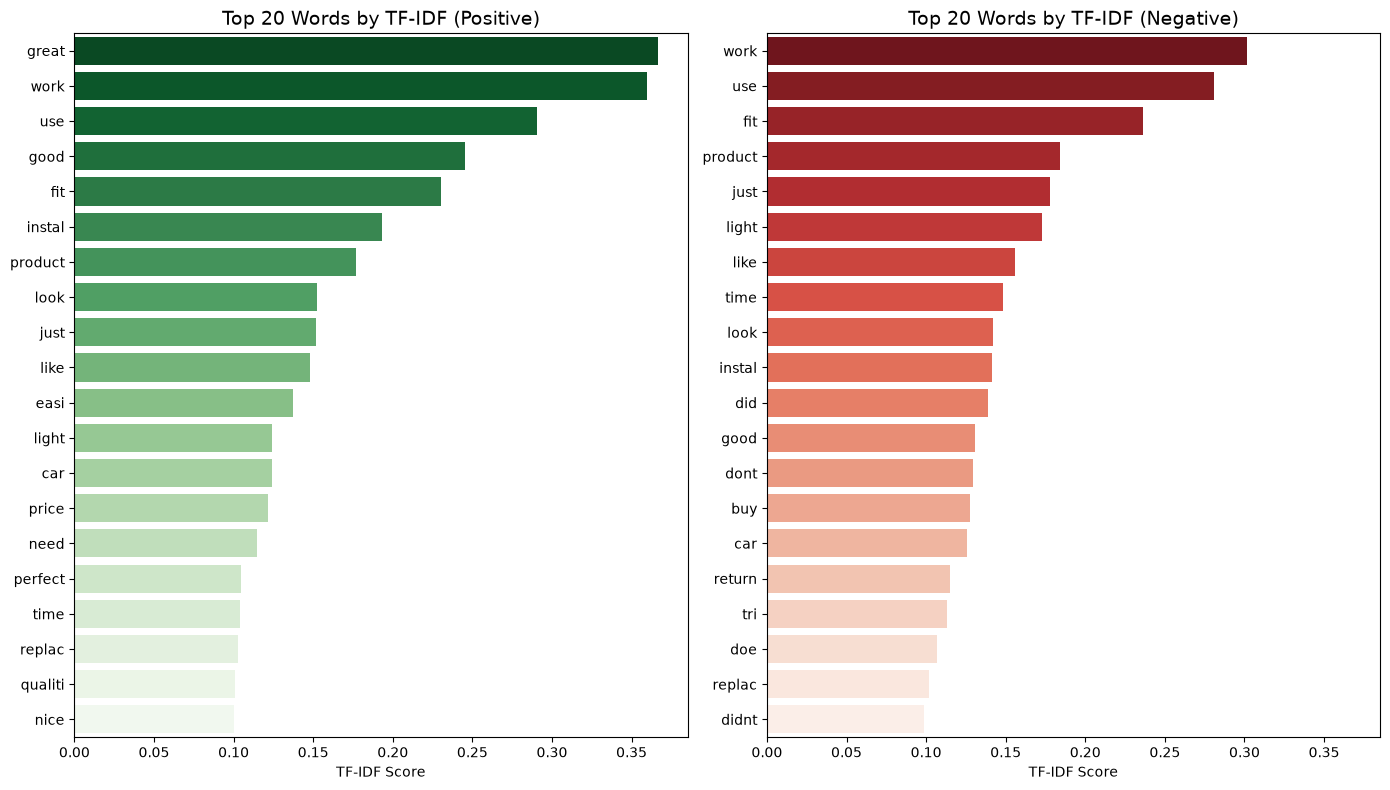

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

top_k = 20

top_pos_idx = pos_scores.argsort()[::-1][:top_k]
top_neg_idx = neg_scores.argsort()[::-1][:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True)

sns.barplot(
    x=pos_scores[top_pos_idx],
    y=feature_names[top_pos_idx],
    palette='Greens_r',
    ax=axes[0]
)
axes[0].set_title('Top 20 Words by TF-IDF (Positive)', fontsize=14)
axes[0].set_xlabel('TF-IDF Score')

sns.barplot(
    x=neg_scores[top_neg_idx],
    y=feature_names[top_neg_idx],
    palette='Reds_r',
    ax=axes[1]
)
axes[1].set_title('Top 20 Words by TF-IDF (Negative)', fontsize=14)
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()


In [ ]:
%pip install --upgrade pip
%pip install wordcloud

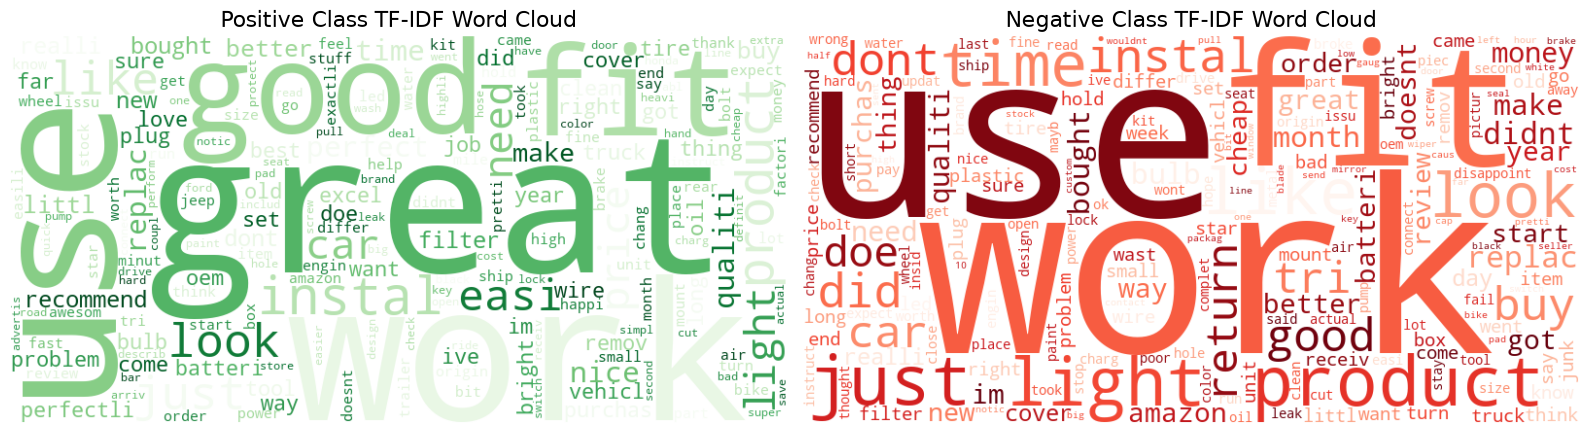

In [66]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

pos_dict = dict(zip(feature_names, pos_scores))
neg_dict = dict(zip(feature_names, neg_scores))

pos_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate_from_frequencies(pos_dict)
neg_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(neg_dict)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Positive Class TF-IDF Word Cloud', fontsize=16)
axes[0].axis('off')

axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Negative Class TF-IDF Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**